In [33]:
import os
import csv
import ast
import pickle
from pathlib import Path
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt
import matplotlib as mpl

import sys
sys.path.insert(0, str(Path("..").resolve()))
from utils import savefig

plt.rcParams['font.size'] = 14

In [38]:
def load_data(path, training_data_path, model_num, exp, paramters, training_data_length=200):
    data_single_model = {}
    with open(path/"contiguity_effect.csv", "r") as f:
        reader = csv.reader(f)
        for row in reader:
            data_single_model["model_num"] = model_num
            data_single_model["exp"] = exp

            for key, value in paramters.items():
                data_single_model[key] = value

            data_single_model["accuracy"] = float(row[0])
            data_single_model["forward_asymmetry"] = float(row[1]) 
            data_single_model["temporal_factor"] = float(row[2]) * 4/3

            classifier_data = pickle.load(open(path/"ridge_classifier_stat.pkl", "rb"))
            data_single_model["index_decoding_accuracy_encoding_phase"] = classifier_data["index_enc_acc"]
            data_single_model["item_decoding_accuracy_encoding_phase"] = classifier_data["item_enc_acc"]
            data_single_model["last_item_decoding_accuracy_encoding_phase"] = classifier_data["item_enc_acc_last"]
            data_single_model["index_decoding_accuracy_recall_phase"] = classifier_data["index_rec_acc"]
            data_single_model["item_decoding_accuracy_recall_phase"] = classifier_data["item_rec_acc"]
            data_single_model["last_item_decoding_accuracy_recall_phase"] = classifier_data["item_rec_acc_last"]
            data_single_model["index_decoding_accuracy"] = (data_single_model["index_decoding_accuracy_encoding_phase"] + data_single_model["index_decoding_accuracy_recall_phase"]) / 2
            data_single_model["item_decoding_accuracy"] = (data_single_model["item_decoding_accuracy_encoding_phase"] + data_single_model["item_decoding_accuracy_recall_phase"]) / 2
            data_single_model["last_item_decoding_accuracy"] = (data_single_model["last_item_decoding_accuracy_encoding_phase"] + data_single_model["last_item_decoding_accuracy_recall_phase"]) / 2

            explained_variance_data = np.load(path/"explained_variance.npy")
            data_single_model["explained_variance_encoding_index"] = explained_variance_data[0]
            data_single_model["explained_variance_recall_index"] = explained_variance_data[1]
            data_single_model["explained_variance_index"] = (data_single_model["explained_variance_encoding_index"] + data_single_model["explained_variance_recall_index"]) / 2
            data_single_model["explained_variance_encoding_identity"] = explained_variance_data[2]
            data_single_model["explained_variance_recall_identity"] = explained_variance_data[3]
            data_single_model["explained_variance_identity"] = (data_single_model["explained_variance_encoding_identity"] + data_single_model["explained_variance_recall_identity"]) / 2

            cross_decoding_data = np.load(path/"cross_acc.npy")
            data_single_model["cross_decoding_accuracy_index_rec_enc"] = cross_decoding_data[0]
            data_single_model["cross_decoding_accuracy_identity_rec_enc"] = cross_decoding_data[1]
            data_single_model["cross_decoding_accuracy_index_enc_rec"] = cross_decoding_data[2]
            data_single_model["cross_decoding_accuracy_identity_enc_rec"] = cross_decoding_data[3]
            data_single_model["cross_decoding_accuracy_index"] = (data_single_model["cross_decoding_accuracy_index_rec_enc"] + data_single_model["cross_decoding_accuracy_index_enc_rec"]) / 2
            data_single_model["cross_decoding_accuracy_identity"] = (data_single_model["cross_decoding_accuracy_identity_rec_enc"] + data_single_model["cross_decoding_accuracy_identity_enc_rec"]) / 2

            try:
                training_data = np.load(training_data_path/"accuracy_2.npy")
            except:
                training_data = np.load(training_data_path/"accuracy_1.npy")
            # find the final consecutive zeros in the training data and set it to the last non-zero value
            zero_indices = np.where(training_data == 0)[0]
            if len(zero_indices) > 0:
                last_zero_index = zero_indices[0]
                training_data[last_zero_index:] = training_data[last_zero_index-1]
            if training_data.shape[0] < training_data_length and training_data.shape[0] > 0:
                training_data = np.pad(training_data, (0, training_data_length - training_data.shape[0]), mode='constant', constant_values=training_data[-1])
            data_single_model["training_accuracy"] = training_data

            f_recall_prob = open(path/"recall_probability.csv", "r")
            for row in f_recall_prob:
                data_single_model["crp_curve"] = [float(x) for x in row.strip().split(",")]
                break
            break
    return data_single_model


In [23]:
data_ctx = []

data_folder = Path("./experiments/ExtraObs/EnvCxt/figures/ValueMemoryGRU")
training_curve_folder = Path("./experiments/ExtraObs/EnvCxt/saved_models/ValueMemoryGRU")


# setup_base_name = "setup_gaussiannoise"
setup_base_name = "setup_gamma09_flush09_gaussiannoise"
# setup_base_name = "setup_dim41_gamma09_flush09_gaussiannoise"
# setup_base_name = "setup_gamma09_flush09_dim41_randnoise"
# setup_names = ["setup_gaussiannoise0", "setup_gaussiannoise02", "setup_gaussiannoise04", "setup_gaussiannoise06", "setup_gaussiannoise08", "setup_gaussiannoise1"]
noise_stds = [0, 0.2, 0.4, 0.8]
# noise_stds = [0, 0.4, 0.8, 1.2]

setup_names = []
for noise_std in noise_stds:
    setup_names.append(setup_base_name + str(noise_std).replace(".", ""))



seq_len = 8

exp = "ctx"

for setup_name, noise_std in zip(setup_names, noise_stds):
    parameters = {
        "noise_std": noise_std,
        "seq_len": seq_len,
        "gamma": 0.9,
        "flush_noise": 0.9
    }
    
    training_data_length = 200
    for i in range(20):
        data_path = data_folder / setup_name / str(i)
        training_data_path = training_curve_folder / (setup_name + "-" + str(i))
        if os.path.exists(data_path/"contiguity_effect.csv") and os.path.exists(data_path/"cross_acc.npy"):
            data_single_model = load_data(data_path, training_data_path, i, exp, parameters, training_data_length)
            if data_single_model:
                data_single_model["pretrained"] = False
                data_ctx.append(data_single_model)

df_ctx = pd.DataFrame(data_ctx)
df_ctx = df_ctx[df_ctx["accuracy"] > 0.7]
print(len(df_ctx))

64


In [24]:
# data_ctx = []

data_folder = Path("./experiments/ExtraObs/EnvCxt/figures/ValueMemoryGRU")
training_curve_folder = Path("./experiments/ExtraObs/EnvCxt/saved_models/ValueMemoryGRU")


# setup_base_name = "setup_gaussiannoise"
setup_base_name = "setup_gaussiannoise"
# setup_names = ["setup_gaussiannoise0", "setup_gaussiannoise02", "setup_gaussiannoise04", "setup_gaussiannoise06", "setup_gaussiannoise08", "setup_gaussiannoise1"]
noise_stds = [0, 0.2, 0.4, 0.8]
# noise_stds = [0, 0.4, 0.8, 1.2]

setup_names = []
for noise_std in noise_stds:
    setup_names.append(setup_base_name + str(noise_std).replace(".", ""))

seq_len = 8

exp = "ctx"

for setup_name, noise_std in zip(setup_names, noise_stds):
    parameters = {
        "noise_std": noise_std,
        "seq_len": seq_len,
        "gamma": 1.0,
        "flush_noise": 1.0
    }
    
    training_data_length = 200
    for i in range(10, 20):
        data_path = data_folder / setup_name / str(i)
        training_data_path = training_curve_folder / (setup_name + "-" + str(i))
        if os.path.exists(data_path/"contiguity_effect.csv") and os.path.exists(data_path/"cross_acc.npy"):
            data_single_model = load_data(data_path, training_data_path, i, exp, parameters, training_data_length)
            if data_single_model:
                data_single_model["pretrained"] = False
                data_ctx.append(data_single_model)

df_ctx = pd.DataFrame(data_ctx)
df_ctx = df_ctx[df_ctx["accuracy"] > 0.7]
print(len(df_ctx))

102


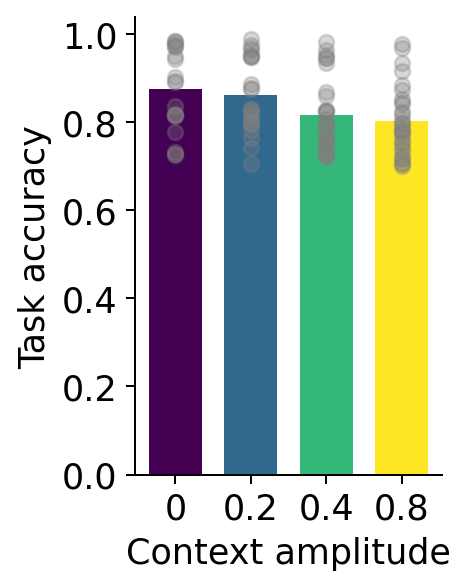

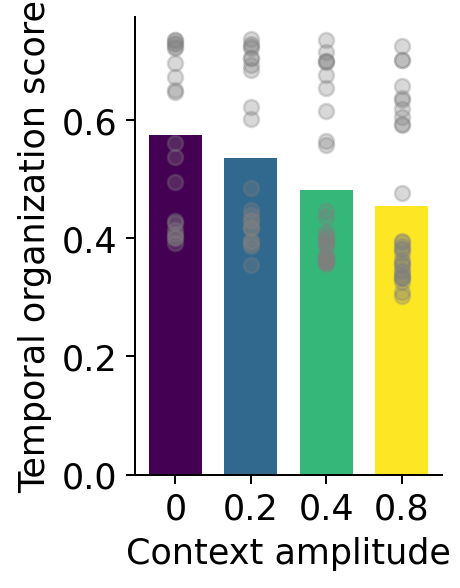

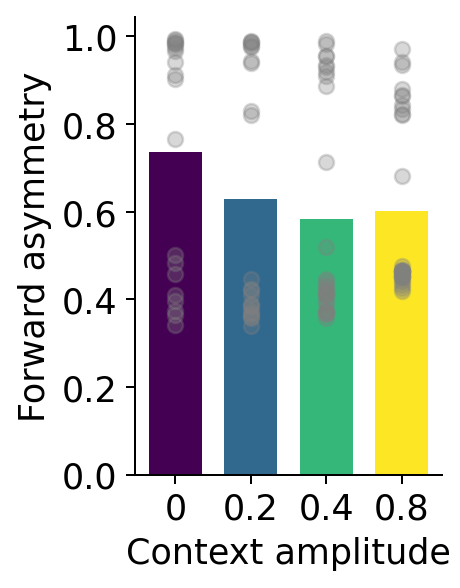

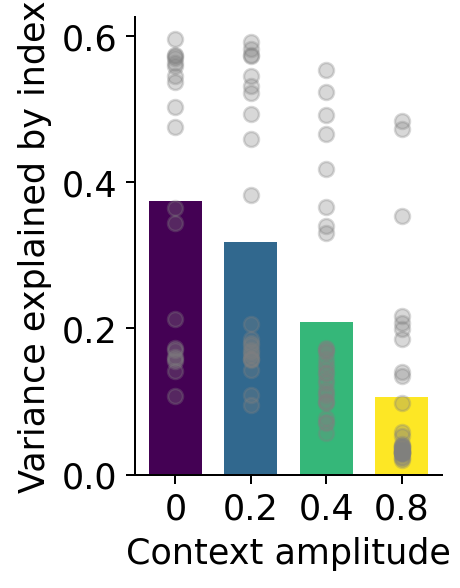

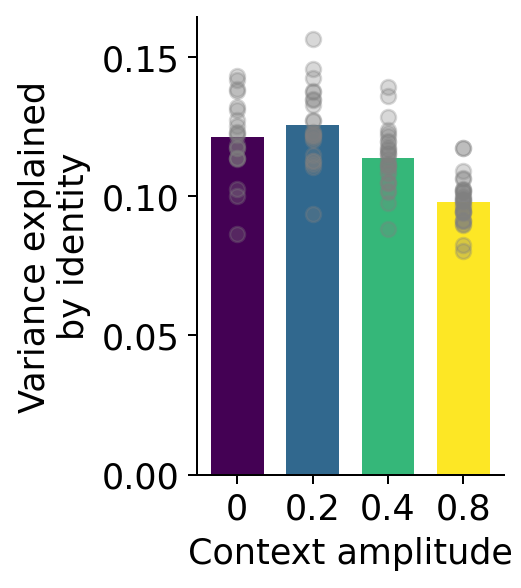

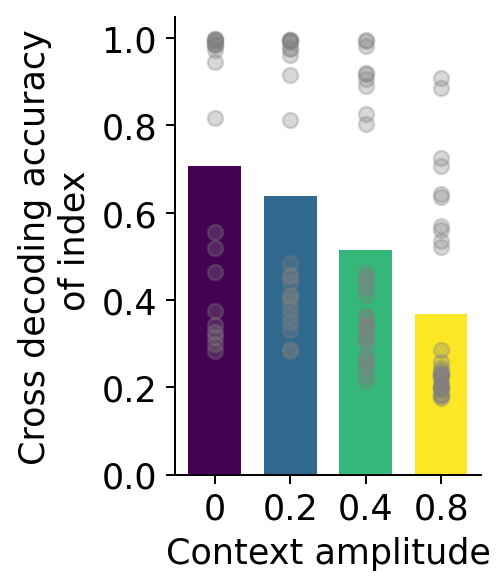

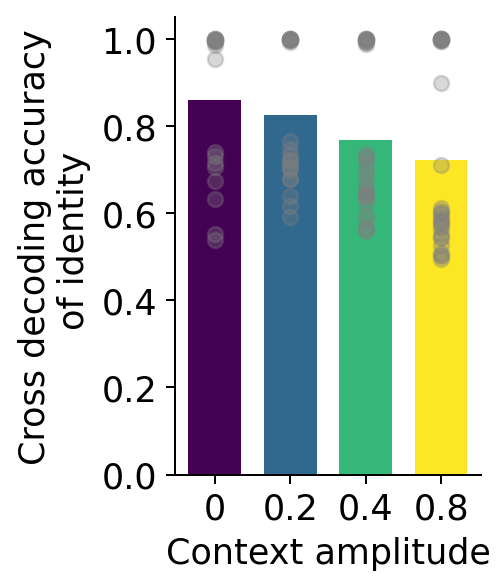

In [25]:
# bar plot of each metric for each noise std

accuracy_mean_by_noise_std = df_ctx.groupby("noise_std")["accuracy"].mean()
accuracy_std_by_noise_std = df_ctx.groupby("noise_std")["accuracy"].std()

temporal_factor_mean_by_noise_std = df_ctx.groupby("noise_std")["temporal_factor"].mean()
temporal_factor_std_by_noise_std = df_ctx.groupby("noise_std")["temporal_factor"].std()

forward_asymmetry_mean_by_noise_std = df_ctx.groupby("noise_std")["forward_asymmetry"].mean()
forward_asymmetry_std_by_noise_std = df_ctx.groupby("noise_std")["forward_asymmetry"].std()

variance_explained_index_mean_by_noise_std = df_ctx.groupby("noise_std")["explained_variance_index"].mean()
variance_explained_identity_mean_by_noise_std = df_ctx.groupby("noise_std")["explained_variance_identity"].mean()

cross_decoding_accuracy_index_mean_by_noise_std = df_ctx.groupby("noise_std")["cross_decoding_accuracy_index"].mean()
cross_decoding_accuracy_identity_mean_by_noise_std = df_ctx.groupby("noise_std")["cross_decoding_accuracy_identity"].mean()


viridis = plt.get_cmap('viridis', lut=len(noise_stds))
colors = [viridis(i) for i in range(len(noise_stds))]

noise_std_nums = np.arange(len(noise_stds))
df_ctx["noise_std_num"] = df_ctx["noise_std"].map(lambda x: noise_std_nums[noise_stds.index(x)])

def plot_mean_scatter_bar(mean, df, df_label, noise_stds, y_label):
    plt.figure(figsize=(2.2, 3.3), dpi=180)
    plt.bar(np.arange(len(noise_stds)), mean, width=0.7, color=colors)
    plt.xticks(np.arange(len(noise_stds)), noise_stds)
    plt.scatter(df["noise_std_num"], df[df_label], color="gray", alpha=0.3)
    plt.xlabel("Context amplitude")
    plt.ylabel(y_label)
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.show()

plot_mean_scatter_bar(accuracy_mean_by_noise_std, df_ctx, "accuracy", noise_stds, "Task accuracy")
plot_mean_scatter_bar(temporal_factor_mean_by_noise_std, df_ctx, "temporal_factor", noise_stds, "Temporal organization score")
plot_mean_scatter_bar(forward_asymmetry_mean_by_noise_std, df_ctx, "forward_asymmetry", noise_stds, "Forward asymmetry")
plot_mean_scatter_bar(variance_explained_index_mean_by_noise_std, df_ctx, "explained_variance_index", noise_stds, "Variance explained by index")
plot_mean_scatter_bar(variance_explained_identity_mean_by_noise_std, df_ctx, "explained_variance_identity", noise_stds, "Variance explained\nby identity")
plot_mean_scatter_bar(cross_decoding_accuracy_index_mean_by_noise_std, df_ctx, "cross_decoding_accuracy_index", noise_stds, "Cross decoding accuracy\n of index")
plot_mean_scatter_bar(cross_decoding_accuracy_identity_mean_by_noise_std, df_ctx, "cross_decoding_accuracy_identity", noise_stds, "Cross decoding accuracy\n of identity")


In [21]:
def plot_crp_by_group(data, group_values, group_title, colors):
    plt.figure(figsize=(3.5, 3), dpi=180)

    print(data.shape[1])

    mid_point = data.shape[1] // 2 + 1

    print(mid_point)

    data[:, mid_point] += data[:, 0]
    data[:, 0] = 0

    for i in range(len(group_values)):
        plt.plot(np.arange(-mid_point+1, 0), data[i, :mid_point-1], label=group_values[i], color=colors[i])
        plt.plot(np.arange(1, mid_point), data[i, mid_point:], color=colors[i])
    
    plt.xlabel("Lag")
    plt.ylabel("Conditional\nrecall probability")
    plt.legend(
        title=group_title, 
        bbox_to_anchor=(1.0, 1.0), 
        loc="upper left", 
        borderaxespad=0, 
        frameon=False
    )
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.show()

15
8


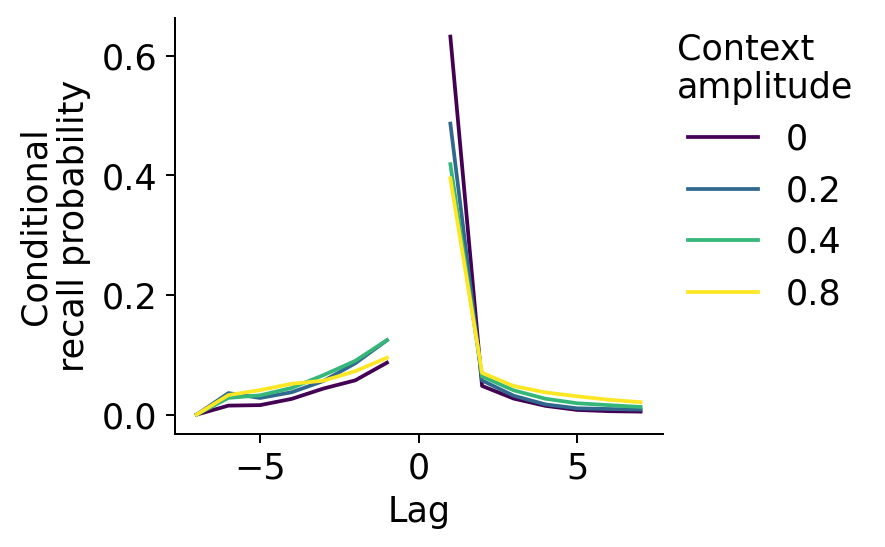

In [26]:
crp_by_noise_std = df_ctx.groupby("noise_std")["crp_curve"]
# print(crp_by_noise_std.head())
mean_crp_by_noise_std = []
for name, group in crp_by_noise_std:
    crp_arrays = np.array(group.tolist())
    mean_crp = np.mean(np.stack(crp_arrays, axis=0), axis=0)
    mean_crp_by_noise_std.append(mean_crp)
mean_crp_by_noise_std = np.array(mean_crp_by_noise_std)

viridis = plt.get_cmap('viridis', lut=len(noise_stds))
colors = [viridis(i) for i in range(len(noise_stds))]

plot_crp_by_group(mean_crp_by_noise_std, noise_stds, "Context\namplitude", colors)



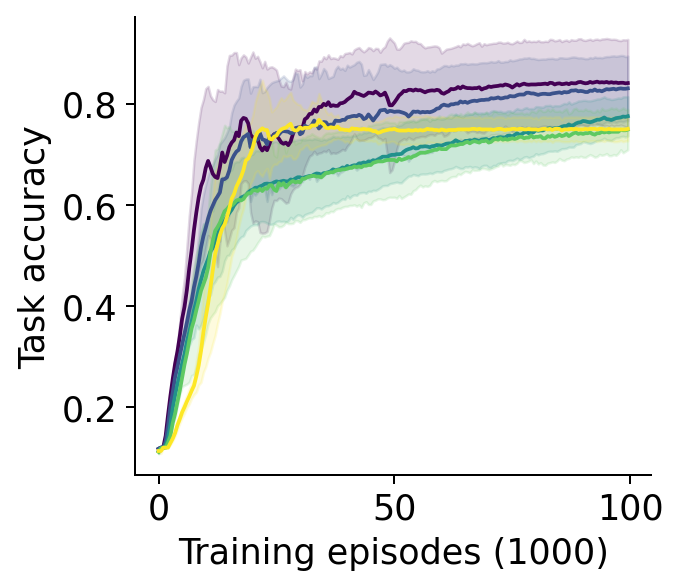

In [8]:
# training_accuracy_by_tdf = df_tdf[(df_tdf["pretrained"] == True) & (df_tdf["eta"] == 0.01)].groupby("temporal_discount_factor")["training_accuracy"].mean()
training_accuracy_by_noise_std = df_ctx.groupby("noise_std")["training_accuracy"].mean()

plt.figure(figsize=(3.7, 3.3), dpi=180)
colors = plt.cm.viridis(np.linspace(0, 1, len(training_accuracy_by_noise_std)))
for i, (noise_std, acc) in enumerate(training_accuracy_by_noise_std.items()):
    plt.plot(acc[:200], label=f"noise std = {noise_std:.1f}", color=colors[i])
    std_dev = np.std(np.stack(df_ctx[df_ctx["noise_std"] == noise_std]["training_accuracy"]), axis=0)
    plt.fill_between(range(len(acc[:200])), acc[:200] - std_dev, acc[:200] + std_dev, color=colors[i], alpha=0.15)
    
# set the legend to the right of the plot
ax = plt.gca()
# ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)
plt.xticks(np.arange(0, 201, 100), np.arange(0, 101, 50))
plt.xlabel("Training episodes (1000)")
plt.ylabel("Task accuracy")
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.show()


In [39]:
data_samediff = []

data_folder = Path("./experiments/ExtraObs/RecallCtx/figures/ValueMemoryGRU")
training_curve_folder = Path("./experiments/ExtraObs/RecallCtx/saved_models/ValueMemoryGRU")

# setup_names = ["setup_gaussiannoise04_dim41_baseline", "setup_gaussiannoise04_dim41_same", "setup_gaussiannoise04_dim41_diff"]
# setup_names = ["setup_gaussiannoise1_baseline", "setup_gaussiannoise1_same", "setup_gaussiannoise1_diff"]
# setup_names = ["setup_gaussiannoise04_dim41_gamma09_flush09_baseline", "setup_gaussiannoise04_dim41_gamma09_flush09_same2", "setup_gaussiannoise04_dim41_gamma09_flush09_diff2"]
setup_names = ["setup_gaussiannoise04_dim41_gamma09_flush09_same2", "setup_gaussiannoise04_dim41_gamma09_flush09_diff2"]
# setup_names = ["setup_gaussiannoise03_dim41_flush0_continuous", "setup_gaussiannoise03_dim41_flush0_same", "setup_gaussiannoise03_dim41_flush0_diff"]
noise_types = ["same", "diff"]

seq_len = 8

exp = "ctx"

for setup_name, noise_type in zip(setup_names, noise_types):
    parameters = {
        "noise_type": noise_type,
        "seq_len": seq_len,
        "test_noise_type": "same"
    }
    
    training_data_length = 200
    for i in range(20):
        data_path = data_folder / (setup_name+"_testsame") / str(i)
        training_data_path = training_curve_folder / (setup_name + "-" + str(i))
        if os.path.exists(data_path/"contiguity_effect.csv") and os.path.exists(data_path/"cross_acc.npy"):
            data_single_model = load_data(data_path, training_data_path, i, exp, parameters, training_data_length)
            if data_single_model:
                data_single_model["pretrained"] = False
                data_samediff.append(data_single_model)

for setup_name, noise_type in zip(setup_names, noise_types):
    parameters = {
        "noise_type": noise_type,
        "seq_len": seq_len,
        "test_noise_type": "diff"
    }
    
    training_data_length = 200
    for i in range(20):
        data_path = data_folder / (setup_name+"_testdiff")/ str(i)
        training_data_path = training_curve_folder / (setup_name + "-" + str(i))
        if os.path.exists(data_path/"contiguity_effect.csv") and os.path.exists(data_path/"cross_acc.npy"):
            data_single_model = load_data(data_path, training_data_path, i, exp, parameters, training_data_length)
            if data_single_model:
                data_single_model["pretrained"] = False
                data_samediff.append(data_single_model)

setup_name = "setup_gaussiannoise04_dim41_gamma09_flush09_fixed2"
noise_type = "fixed"
parameters = {
    "noise_type": noise_type,
    "seq_len": seq_len,
    "test_noise_type": "fixed"
}

training_data_length = 200
for i in range(20):
    data_path = data_folder / (setup_name) / str(i)
    training_data_path = training_curve_folder / (setup_name + "-" + str(i))
    if os.path.exists(data_path/"contiguity_effect.csv") and os.path.exists(data_path/"cross_acc.npy"):
        data_single_model = load_data(data_path, training_data_path, i, exp, parameters, training_data_length)
        if data_single_model:
            data_single_model["pretrained"] = False
            data_samediff.append(data_single_model)


df_samediff = pd.DataFrame(data_samediff)
print(len(df_samediff))

100


In [40]:
filter_model_nums = df_samediff[(df_samediff["noise_type"] == "same") & (df_samediff["test_noise_type"] == "same") & (df_samediff["accuracy"] > 0.5)]["model_num"].tolist()
print(filter_model_nums)
filter_model_nums2 = df_samediff[(df_samediff["noise_type"] == "diff") & (df_samediff["test_noise_type"] == "diff") & (df_samediff["accuracy"] > 0.5)]["model_num"].tolist()
print(filter_model_nums2)
df_samediff = df_samediff[(df_samediff["noise_type"] == "same") & (df_samediff["model_num"].isin(filter_model_nums)) |
                         (df_samediff["noise_type"] == "diff") & (df_samediff["model_num"].isin(filter_model_nums2)) |
                         (df_samediff["noise_type"] == "fixed")]
# df_samediff = df_samediff[df_samediff["accuracy"] > 0.5]
print(len(df_samediff))

# df_samediff["noise_type_int"] = df_samediff["noise_type"].map({"no": 0, "same": 1, "diff": 2})
df_samediff["noise_type_int"] = df_samediff["noise_type"].map({"same": 1, "diff": 2, "fixed": 0})
df_samediff["test_noise_type_int"] = df_samediff["test_noise_type"].map({"same": 1, "diff": 2, "fixed": 0})
df_samediff["mark"] = (df_samediff["noise_type_int"]-1).clip(lower=0) * 2 + df_samediff["test_noise_type_int"]
# df_samediff[df_samediff["noise_type"] == "fixed"].loc[:, "mark"] = 0
# print(df_samediff["mark"])

[0, 1, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19]
[0, 1, 3, 5, 6, 8, 9, 10, 11, 12, 13, 14, 17, 18, 19]
86


noise_type_int  test_noise_type_int
0               0                      0.921462
1               1                      0.826069
                2                      0.688451
2               1                      0.684383
                2                      0.682417
Name: accuracy, dtype: float64


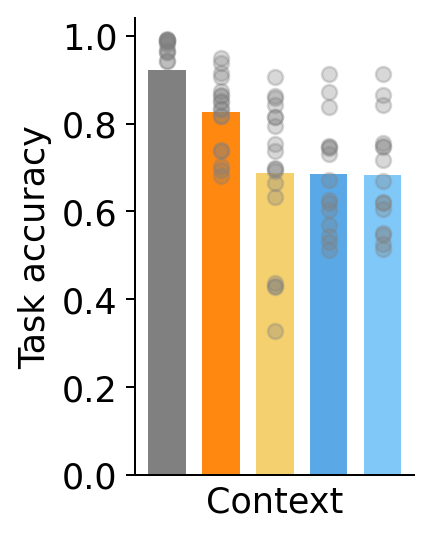

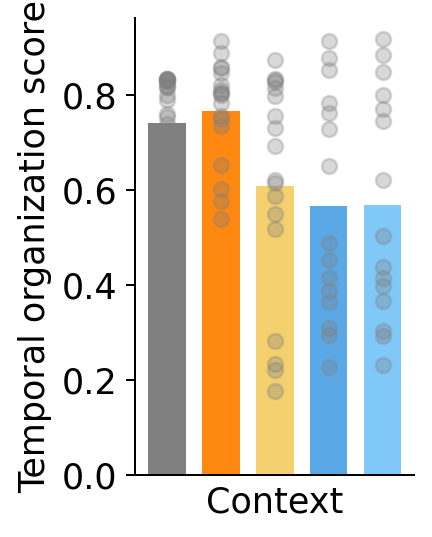

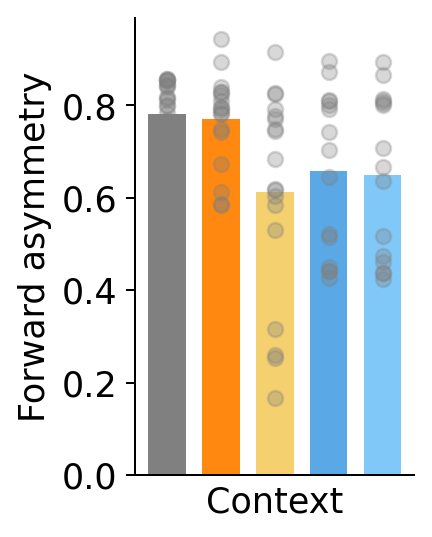

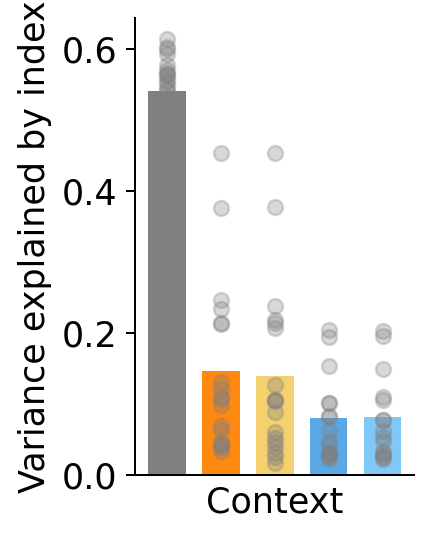

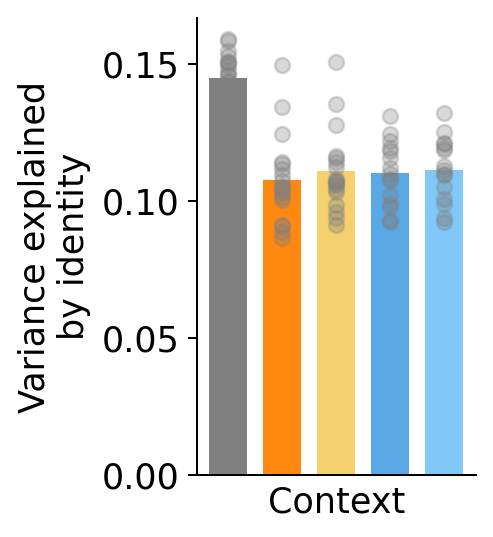

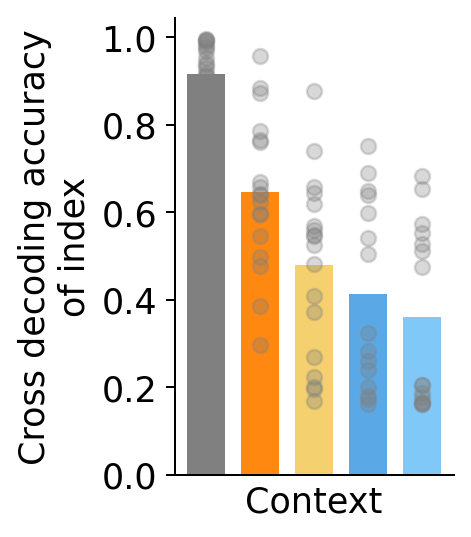

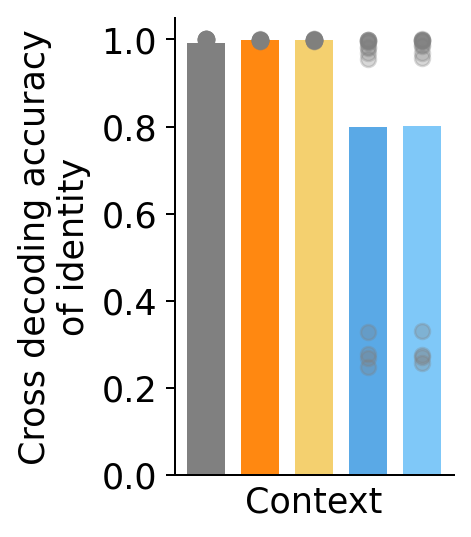

In [41]:
# bar plot of each metric for each noise std

# accuracy_mean_by_noise_type = df_samediff.groupby("noise_type_int",)["accuracy"].mean()
# accuracy_std_by_noise_type = df_samediff.groupby("noise_type_int")["accuracy"].std()

# temporal_factor_mean_by_noise_type = df_samediff.groupby("noise_type_int")["temporal_factor"].mean()
# temporal_factor_std_by_noise_type = df_samediff.groupby("noise_type_int")["temporal_factor"].std()

# forward_asymmetry_mean_by_noise_type = df_samediff.groupby("noise_type_int")["forward_asymmetry"].mean()
# forward_asymmetry_std_by_noise_type = df_samediff.groupby("noise_type_int")["forward_asymmetry"].std()

# variance_explained_index_mean_by_noise_type = df_samediff.groupby("noise_type_int")["explained_variance_index"].mean()
# variance_explained_identity_mean_by_noise_type = df_samediff.groupby("noise_type_int")["explained_variance_identity"].mean()

# cross_decoding_accuracy_index_mean_by_noise_type = df_samediff.groupby("noise_type_int")["cross_decoding_accuracy_index"].mean()
# cross_decoding_accuracy_identity_mean_by_noise_type = df_samediff.groupby("noise_type_int")["cross_decoding_accuracy_identity"].mean()

accuracy_mean_by_noise_type = df_samediff.groupby(["noise_type_int", "test_noise_type_int"])["accuracy"].mean()
accuracy_std_by_noise_type = df_samediff.groupby(["noise_type_int", "test_noise_type_int"])["accuracy"].std()
print(accuracy_mean_by_noise_type)

temporal_factor_mean_by_noise_type = df_samediff.groupby(["noise_type_int", "test_noise_type_int"])["temporal_factor"].mean()
temporal_factor_std_by_noise_type = df_samediff.groupby(["noise_type_int", "test_noise_type_int"])["temporal_factor"].std()

forward_asymmetry_mean_by_noise_type = df_samediff.groupby(["noise_type_int", "test_noise_type_int"])["forward_asymmetry"].mean()
forward_asymmetry_std_by_noise_type = df_samediff.groupby(["noise_type_int", "test_noise_type_int"])["forward_asymmetry"].std()

variance_explained_index_mean_by_noise_type = df_samediff.groupby(["noise_type_int", "test_noise_type_int"])["explained_variance_index"].mean()
variance_explained_identity_mean_by_noise_type = df_samediff.groupby(["noise_type_int", "test_noise_type_int"])["explained_variance_identity"].mean()

cross_decoding_accuracy_index_mean_by_noise_type = df_samediff.groupby(["noise_type_int", "test_noise_type_int"])["cross_decoding_accuracy_index"].mean()
cross_decoding_accuracy_identity_mean_by_noise_type = df_samediff.groupby(["noise_type_int", "test_noise_type_int"])["cross_decoding_accuracy_identity"].mean()


# colors = ["black", "tab:blue", "tab:red"]
colors = ["grey", "#FF8811", "#F4D06F", "#5AA9E6", "#7FC8F8"]

def plot_mean_scatter_bar(mean, df, df_label, y_label):
    plt.figure(figsize=(2, 3.3), dpi=180)
    plt.bar(np.arange(len(mean)), mean, width=0.7, color=colors)
    plt.scatter(df["mark"], df[df_label], color="gray", alpha=0.3)
    # plt.xticks(np.arange(3), ["baseline", "same", "diff"], fontsize=12, rotation=30)
    plt.xticks([])
    plt.xlabel("Context")
    plt.ylabel(y_label)
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.show()

# print(df_samediff["noise_type"])
plot_mean_scatter_bar(accuracy_mean_by_noise_type, df_samediff, "accuracy", "Task accuracy")
plot_mean_scatter_bar(temporal_factor_mean_by_noise_type, df_samediff, "temporal_factor", "Temporal organization score")
plot_mean_scatter_bar(forward_asymmetry_mean_by_noise_type, df_samediff, "forward_asymmetry", "Forward asymmetry")
plot_mean_scatter_bar(variance_explained_index_mean_by_noise_type, df_samediff, "explained_variance_index", "Variance explained by index")
plot_mean_scatter_bar(variance_explained_identity_mean_by_noise_type, df_samediff, "explained_variance_identity", "Variance explained\nby identity")
plot_mean_scatter_bar(cross_decoding_accuracy_index_mean_by_noise_type, df_samediff, "cross_decoding_accuracy_index", "Cross decoding accuracy\nof index")
plot_mean_scatter_bar(cross_decoding_accuracy_identity_mean_by_noise_type, df_samediff, "cross_decoding_accuracy_identity", "Cross decoding accuracy\nof identity")


15
8


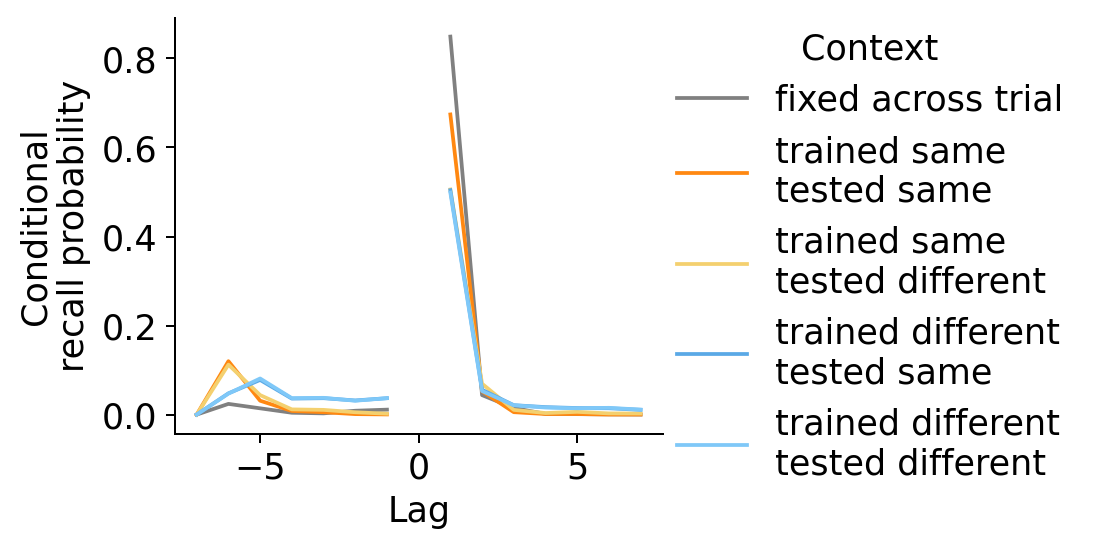

In [16]:
crp_by_noise_std = df_samediff.groupby(["noise_type_int", "test_noise_type_int"])["crp_curve"]
# print(crp_by_noise_std.head())
mean_crp_by_noise_std = []
for name, group in crp_by_noise_std:
    crp_arrays = np.array(group.tolist())
    mean_crp = np.mean(np.stack(crp_arrays, axis=0), axis=0)
    mean_crp_by_noise_std.append(mean_crp)
mean_crp_by_noise_std = np.array(mean_crp_by_noise_std)

# colors = ["black", "tab:blue", "tab:red"]
plot_crp_by_group(mean_crp_by_noise_std, ["fixed across trial", "trained same\ntested same", "trained same\ntested different", "trained different\ntested same", "trained different\ntested different"], "Context", colors)


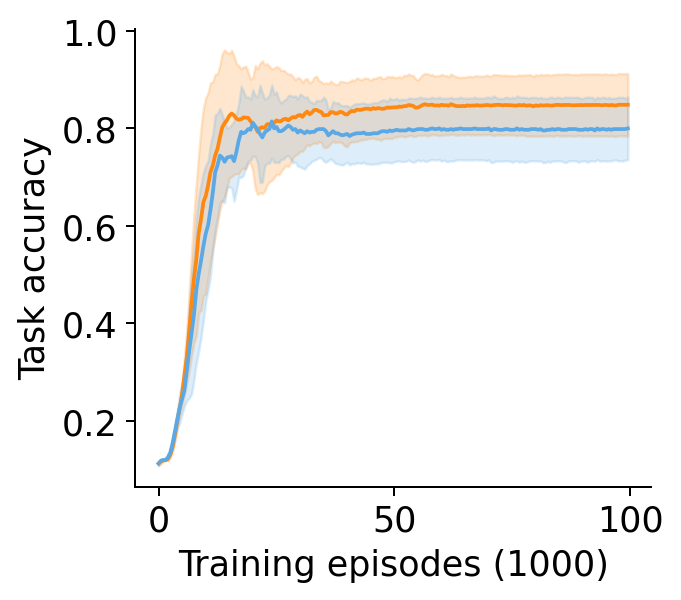

In [43]:
# training_accuracy_by_tdf = df_tdf[(df_tdf["pretrained"] == True) & (df_tdf["eta"] == 0.01)].groupby("temporal_discount_factor")["training_accuracy"].mean()
df_samediff = df_samediff[df_samediff["accuracy"] > 0.6]
training_accuracy_by_noise_type = df_samediff.groupby("noise_type_int")["training_accuracy"].mean()

plt.figure(figsize=(3.7, 3.3), dpi=180)
colors = ["#FF8811", "#5AA9E6"]
for i, (noise_type, acc) in enumerate(training_accuracy_by_noise_type.items()):
    plt.plot(acc[:200], label=f"noise std = {noise_std:.1f}", color=colors[i])
    std_dev = np.std(np.stack(df_samediff[df_samediff["noise_type_int"] == noise_type]["training_accuracy"]), axis=0)
    plt.fill_between(range(len(acc[:200])), acc[:200] - std_dev, acc[:200] + std_dev, color=colors[i], alpha=0.2)
    
# set the legend to the right of the plot
ax = plt.gca()
# ax.legend(loc="center left", bbox_to_anchor=(1, 0.5), frameon=False)
plt.xticks(np.arange(0, 201, 100), np.arange(0, 101, 50))
plt.xlabel("Training episodes (1000)")
plt.ylabel("Task accuracy")
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)
plt.show()


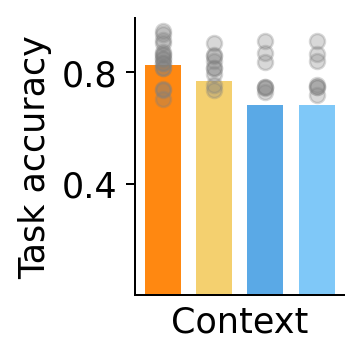

In [54]:
# plt.figure(figsize=(2, 2), dpi=180)
# perf_grid = accuracy_mean_by_noise_type.values.reshape(2, 2)
# cmap = plt.cm.RdYlBu_r
# norm = plt.Normalize(0.5, 1)
# plt.imshow(perf_grid, cmap=cmap, norm=norm)
# plt.colorbar(cmap=cmap, norm=norm, label="Task accuracy")
# plt.xticks([0, 1], ["same", "different"], rotation=30)
# plt.yticks([0, 1], ["same", "different"])
# plt.xlabel("Test context")
# plt.ylabel("Training context")
# plt.show()

colors = ["#FF8811", "#F4D06F", "#5AA9E6", "#7FC8F8"]
plt.figure(figsize=(1.5, 2), dpi=180)
plt.bar(np.arange(len(accuracy_mean_by_noise_type)), accuracy_mean_by_noise_type, width=0.7, color=colors)
plt.scatter(df_samediff["mark"], df_samediff["accuracy"], color="gray", alpha=0.3)
# plt.xticks(np.arange(3), ["baseline", "same", "diff"], fontsize=12, rotation=30)
plt.xticks([])
plt.xlabel("Context")
plt.ylabel("Task accuracy")
plt.yticks([0.4, 0.8])
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

In [9]:
data_samediff = []

data_folder = Path("./experiments/ExtraObs/RecallCtx/figures/ValueMemoryGRU")
training_curve_folder = Path("./experiments/ExtraObs/RecallCtx/saved_models/ValueMemoryGRU")

# setup_names = ["setup_gaussiannoise04_dim41_baseline", "setup_gaussiannoise04_dim41_same", "setup_gaussiannoise04_dim41_diff"]
# setup_names = ["setup_gaussiannoise1_baseline", "setup_gaussiannoise1_same", "setup_gaussiannoise1_diff"]
setup_names = ["setup_gaussiannoise04_dim41_gamma09_flush09_fixed2", "setup_gaussiannoise04_dim41_gamma09_flush09_same2", "setup_gaussiannoise04_dim41_gamma09_flush09_diff2"]
# setup_names = ["setup_gaussiannoise04_dim41_gamma09_flush09_same2", "setup_gaussiannoise04_dim41_gamma09_flush09_diff2"]
# setup_names = ["setup_gaussiannoise03_dim41_flush0_continuous", "setup_gaussiannoise03_dim41_flush0_same", "setup_gaussiannoise03_dim41_flush0_diff"]
noise_types = ["fixed", "same", "diff"]

seq_len = 8

exp = "ctx"

for setup_name, noise_type in zip(setup_names, noise_types):
    parameters = {
        "noise_type": noise_type,
        "seq_len": seq_len,
    }
    
    training_data_length = 200
    for i in range(20):
        data_path = data_folder / (setup_name) / str(i)
        training_data_path = training_curve_folder / (setup_name + "-" + str(i))
        if os.path.exists(data_path/"contiguity_effect.csv") and os.path.exists(data_path/"cross_acc.npy"):
            data_single_model = load_data(data_path, training_data_path, i, exp, parameters, training_data_length)
            if data_single_model:
                data_single_model["pretrained"] = False
                data_samediff.append(data_single_model)

# for setup_name, noise_type in zip(setup_names, noise_types):
#     parameters = {
#         "noise_type": noise_type,
#         "seq_len": seq_len,
#         "test_noise_type": "diff"
#     }
    
#     training_data_length = 200
#     for i in range(20):
#         data_path = data_folder / (setup_name+"_testdiff")/ str(i)
#         training_data_path = training_curve_folder / (setup_name + "-" + str(i))
#         if os.path.exists(data_path/"contiguity_effect.csv") and os.path.exists(data_path/"cross_acc.npy"):
#             data_single_model = load_data(data_path, training_data_path, i, exp, parameters, training_data_length)
#             if data_single_model:
#                 data_single_model["pretrained"] = False
#                 data_samediff.append(data_single_model)

df_samediff = pd.DataFrame(data_samediff)
print(len(df_samediff))

60


In [12]:
df_samediff["noise_type_int"] = df_samediff["noise_type"].map({"fixed": 0, "same": 1, "diff": 2})
df_samediff["mark"] = df_samediff["noise_type_int"]

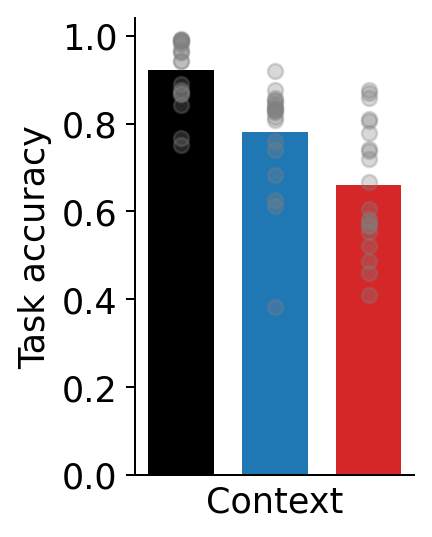

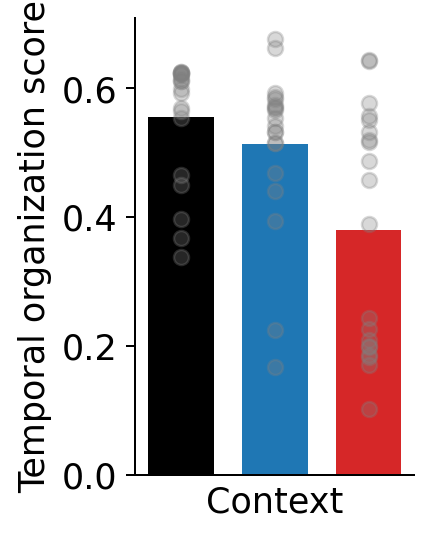

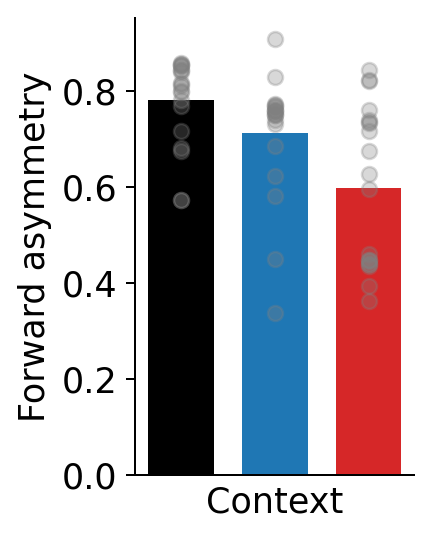

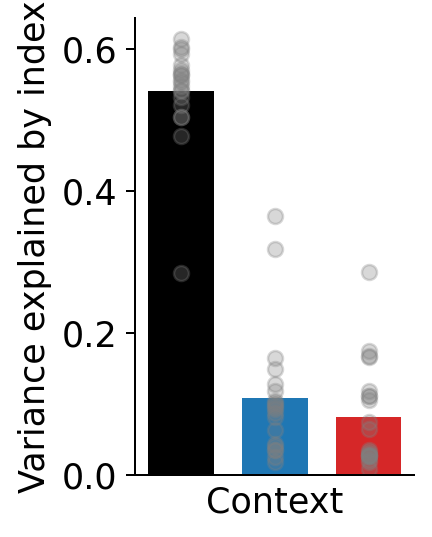

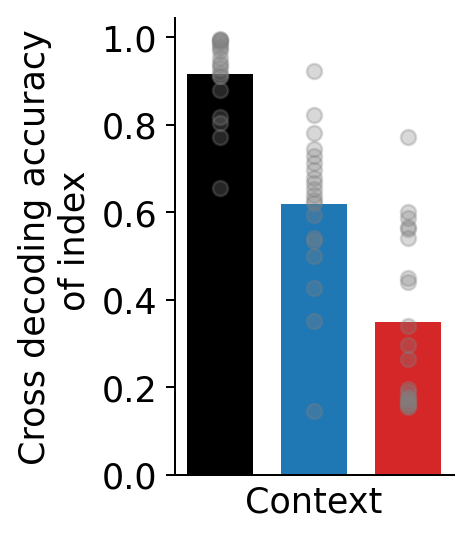

In [ ]:

accuracy_mean_by_noise_type = df_samediff.groupby("noise_type_int",)["accuracy"].mean()
accuracy_std_by_noise_type = df_samediff.groupby("noise_type_int")["accuracy"].std()

temporal_factor_mean_by_noise_type = df_samediff.groupby("noise_type_int")["temporal_factor"].mean()
temporal_factor_std_by_noise_type = df_samediff.groupby("noise_type_int")["temporal_factor"].std()

forward_asymmetry_mean_by_noise_type = df_samediff.groupby("noise_type_int")["forward_asymmetry"].mean()
forward_asymmetry_std_by_noise_type = df_samediff.groupby("noise_type_int")["forward_asymmetry"].std()

variance_explained_index_mean_by_noise_type = df_samediff.groupby("noise_type_int")["explained_variance_index"].mean()
variance_explained_identity_mean_by_noise_type = df_samediff.groupby("noise_type_int")["explained_variance_identity"].mean()

cross_decoding_accuracy_index_mean_by_noise_type = df_samediff.groupby("noise_type_int")["cross_decoding_accuracy_index"].mean()
cross_decoding_accuracy_identity_mean_by_noise_type = df_samediff.groupby("noise_type_int")["cross_decoding_accuracy_identity"].mean()

colors = ["black", "tab:blue", "tab:red"]


def plot_mean_scatter_bar(mean, df, df_label, y_label):
    plt.figure(figsize=(2, 3.3), dpi=180)
    plt.bar(np.arange(len(mean)), mean, width=0.7, color=colors)
    plt.scatter(df["mark"], df[df_label], color="gray", alpha=0.3)
    # plt.xticks(np.arange(3), ["baseline", "same", "diff"], fontsize=12, rotation=30)
    plt.xticks([])
    plt.xlabel("Context")z
    plt.ylabel(y_label)
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.show()

# print(df_samediff["noise_type"])
plot_mean_scatter_bar(accuracy_mean_by_noise_type, df_samediff, "accuracy", "Task accuracy")
plot_mean_scatter_bar(temporal_factor_mean_by_noise_type, df_samediff, "temporal_factor", "Temporal organization score")
plot_mean_scatter_bar(forward_asymmetry_mean_by_noise_type, df_samediff, "forward_asymmetry", "Forward asymmetry")
plot_mean_scatter_bar(variance_explained_index_mean_by_noise_type, df_samediff, "explained_variance_index", "Variance explained by index")
plot_mean_scatter_bar(cross_decoding_accuracy_index_mean_by_noise_type, df_samediff, "cross_decoding_accuracy_index", "Cross decoding accuracy\n of index")



### Semantic information

In [ ]:
data_semantic = []

data_folder = Path("./experiments/Semantic/figures/ValueMemoryGRU")
training_curve_folder = Path("./experiments/Semantic/saved_models/ValueMemoryGRU")
semantic_folder = Path("./experiments/Semantic/figures/semantic/ValueMemoryGRU")


# setup_names = ["setup_extra_hierarchy_amp02", "setup_extra_hierarchy_amp02_gamma0", 
#                 "setup_extra_hierarchy_amp05", "setup_extra_hierarchy_amp05_gamma0", 
#                 "setup_extra_hierarchy_amp02_gamma09_flush09", "setup_extra_hierarchy_amp05_gamma09_flush09",
#                 "setup_extra_sigma02"]
# semantic_type = ["hierarchical_binary", "hierarchical_binary", 
#                 "hierarchical_binary", "hierarchical_binary", 
#                 "hierarchical_binary", "hierarchical_binary", 
#                 "gaussian_identity"]
# semantic_amp = [0.2, 0.2, 0.5, 0.5, 
#                 0.2, 0.5, 
#                 0.2]
# semantic_gamma = [1.0, 0, 1.0, 0, 
#                 0.9, 0.9, 
#                 1.0]
# semantic_flush = [1.0, 1.0, 1.0, 1.0, 
#                 0.9, 0.9, 
#                 1.0]
# marks = np.arange(len(setup_names)) + 1

# setup_name = "setup_extra_hierarchy_amp"
# # semantic_amp = [0.2, 0.3, 0.4, 0.5]
# semantic_amp = [0.3, 0.4, 0.5]
setup_name = "setup_extra_rumelhart_amp"
semantic_amp = [0.5, 1]
setup_names = [setup_name + str(amp).replace(".", "") for amp in semantic_amp]
print(setup_names)
# setup_names = []
# for noise_std in noise_stds:
#     setup_names.append(setup_base_name + str(noise_std).replace(".", ""))



seq_len = 8

exp = "semantic"

for i, setup_name in enumerate(setup_names):
    parameters = {
        # "semantic_type": semantic_type[i],
        "semantic_amp": semantic_amp[i],
        # "semantic_gamma": semantic_gamma[i],
        # "seq_len": seq_len,
        # "mark": marks[i],
    }
    
    training_data_length = 200
    for i in range(20):
        data_path = data_folder / setup_name / str(i)
        training_data_path = training_curve_folder / (setup_name + "-" + str(i))
        if os.path.exists(data_path/"contiguity_effect.csv") and os.path.exists(data_path/"cross_acc.npy"):
            data_single_model = load_data(data_path, training_data_path, i, exp, parameters, training_data_length)
            if data_single_model:
                data_single_model["pretrained"] = False
                semantic_contiguity_data = np.load(semantic_folder / setup_name / str(i) / "data" / "semantic_contiguity_results.npy")
                data_single_model["semantic_contiguity"] = semantic_contiguity_data
                semantic_contiguity_baseline_data = np.load(semantic_folder / setup_name / str(i) / "data" / "semantic_contiguity_baseline.npy")
                data_single_model["semantic_contiguity_baseline"] = semantic_contiguity_baseline_data
                # perturbation_data = np.load(perturbation_folder / setup_name / str(i) / "perturbation_accuracies.npy")
                # data_single_model["perturbation_accuracy"] = perturbation_data
                # if os.path.exists(item_invariance_folder / setup_name / str(i) / "decoding_accuracy.npy"):
                #     item_invariance_data = np.load(item_invariance_folder / setup_name / str(i) / "decoding_accuracy.npy")
                #     data_single_model["item_invariance_accuracy"] = item_invariance_data
                #     item_invariance_cross_phase_data = np.load(item_invariance_folder / setup_name / str(i) / "cross_phase_decoding_accuracy.npy")
                #     data_single_model["item_invariance_cross_phase_accuracy"] = item_invariance_cross_phase_data
                # else:
                #     data_single_model["item_invariance_accuracy"] = None
                #     data_single_model["item_invariance_cross_phase_accuracy"] = None
                # if os.path.exists(time_invariance_folder / setup_name / str(i) / "decoding_accuracy.npy"):
                #     time_invariance_data = np.load(time_invariance_folder / setup_name / str(i) / "decoding_accuracy.npy")
                #     data_single_model["time_invariance_accuracy"] = time_invariance_data
                #     time_invariance_cross_phase_data = np.load(time_invariance_folder / setup_name / str(i) / "cross_phase_decoding_accuracy.npy")
                #     data_single_model["time_invariance_cross_phase_accuracy"] = time_invariance_cross_phase_data
                # else:
                #     data_single_model["time_invariance_accuracy"] = None
                #     data_single_model["time_invariance_cross_phase_accuracy"] = None
                data_semantic.append(data_single_model)

df_semantic = pd.DataFrame(data_semantic)
df_semantic = df_semantic[df_semantic["accuracy"] > 0.7]
print(len(df_semantic))

['setup_extra_rumelhart_amp05', 'setup_extra_rumelhart_amp1']
[]


KeyError: 'accuracy'

(3, 15)
15
8


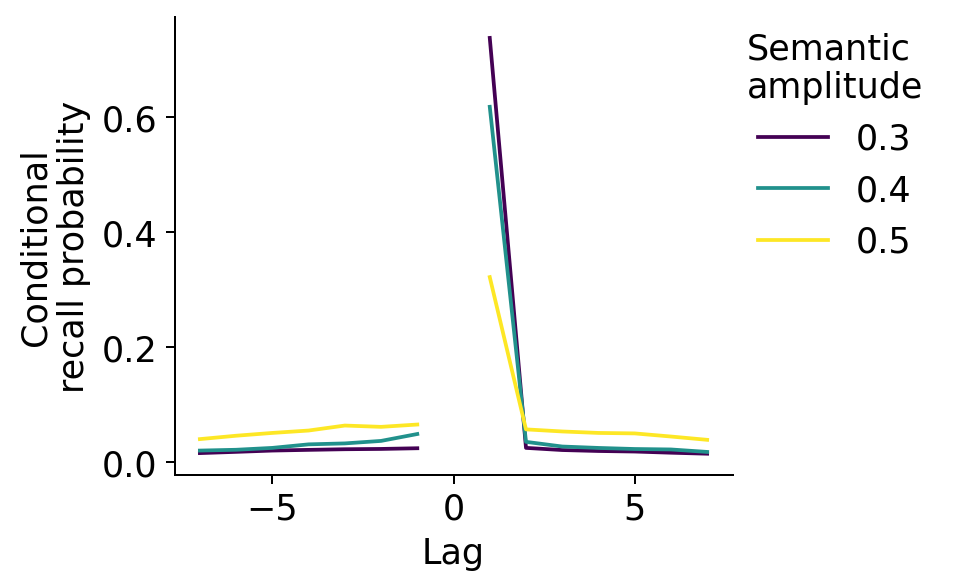

In [65]:
crp_by_noise_std_hier = df_semantic.groupby("semantic_amp")["crp_curve"]
# print(crp_by_noise_std.head())
mean_crp_by_noise_std_hier = []
for name, group in crp_by_noise_std_hier:
    crp_arrays = np.array(group.tolist())
    mean_crp = np.mean(np.stack(crp_arrays, axis=0), axis=0)
    mean_crp_by_noise_std_hier.append(mean_crp)
mean_crp_by_noise_std_hier = np.array(mean_crp_by_noise_std_hier)

print(mean_crp_by_noise_std_hier.shape)

# colors = ["tab:blue", "tab:red", "tab:green", "tab:purple", "tab:orange", "tab:brown"]
# colors = ["#FF8811", "#F4D06F", "#5AA9E6", "#7FC8F8", "tab:blue", "tab:red"]
colors = plt.cm.viridis(np.linspace(0, 1, len(semantic_amp)))
plot_crp_by_group(mean_crp_by_noise_std_hier, semantic_amp, 
                "Semantic\namplitude", colors)


In [60]:
semantic_contiguity = df_semantic.groupby("semantic_amp")["semantic_contiguity"]
semantic_contiguity_baseline = df_semantic.groupby("semantic_amp")["semantic_contiguity_baseline"]

sem_cont_norms = []
for name, group in semantic_contiguity:
    sem_cont_norm = np.array(group.tolist())
    sem_cont_norms.append(sem_cont_norm / np.sum(sem_cont_norm, axis=1, keepdims=True))


sem_cont_norms_baseline = []
for name, group in semantic_contiguity_baseline:
    sem_cont_norm_baseline = np.array(group.tolist())
    sem_cont_norms_baseline.append(sem_cont_norm_baseline / np.sum(sem_cont_norm_baseline, axis=1, keepdims=True))
    # print(sem_cont_norm_baseline.shape)

semantic_contiguity_processed = []
semantic_contiguity_processed_std = []
for i in range(len(sem_cont_norms)):
    sem_count_processed = sem_cont_norms[i] / (sem_cont_norms_baseline[i] + 1e-6)
    data_processed = []
    for j in range(len(sem_count_processed)):
        data_processed.append(sem_count_processed[j])
    data_processed = np.array(data_processed)
    print(data_processed.shape)
    semantic_contiguity_processed.append(np.mean(data_processed, axis=0))
    semantic_contiguity_processed_std.append(np.std(data_processed, axis=0))

# print(sem_cont_norms) 
# print(sem_cont_norms_baseline)
print(semantic_contiguity_processed)

(19, 3)
(19, 3)
(18, 3)
[array([0.98479179, 1.04651558, 1.05572826]), array([0.98454747, 1.05129129, 1.0468925 ]), array([0.95918387, 1.12671462, 1.16754082])]


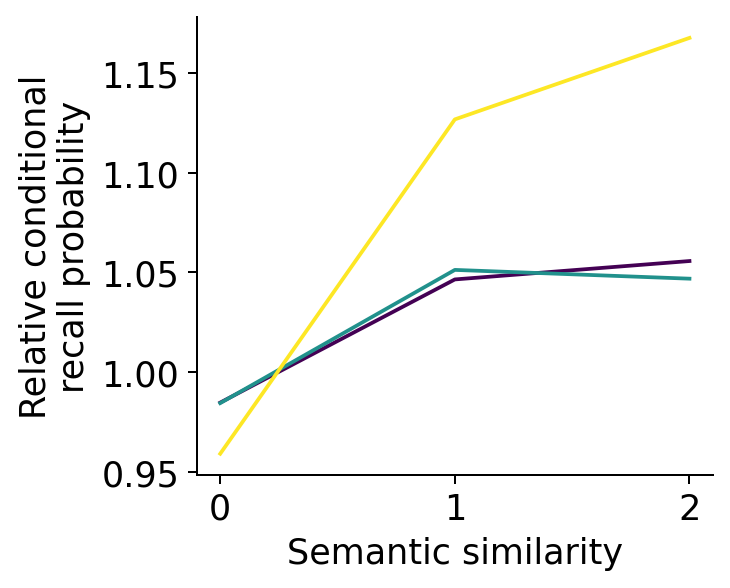

In [66]:
plt.figure(figsize=(3.7, 3.3), dpi=180)
settings_name = semantic_amp
for i in range(len(semantic_contiguity_processed)):
    plt.plot(semantic_contiguity_processed[i], label=settings_name[i], color=colors[i])
    # plt.errorbar(np.arange(len(semantic_contiguity_processed[i])), semantic_contiguity_processed[i], yerr=semantic_contiguity_processed_std[i], color=colors[i], capsize=2)

plt.xticks(np.arange(0, 3), [0, 1, 2])

plt.xlabel("Semantic similarity")
plt.ylabel("Relative conditional\nrecall probability")
# plt.legend(title="Semantic\namplitude", 
#         bbox_to_anchor=(1.0, 1.0), 
#         loc="upper left", 
#         borderaxespad=0, 
#         frameon=False,
#         fontsize=12)
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()



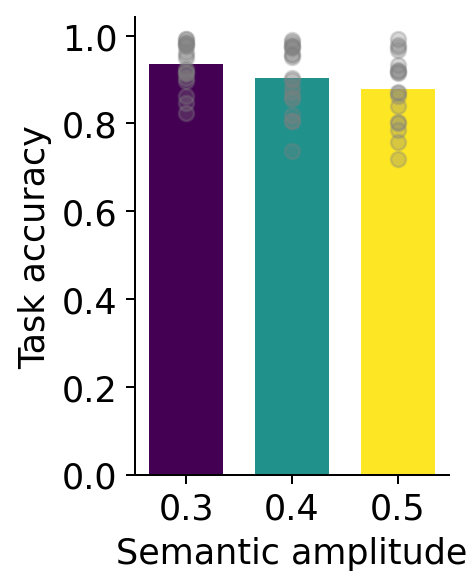

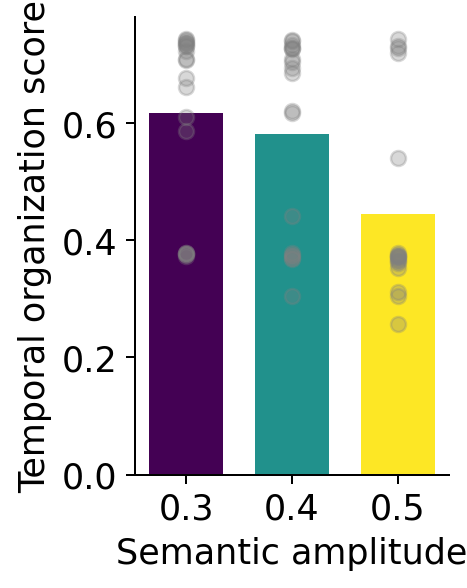

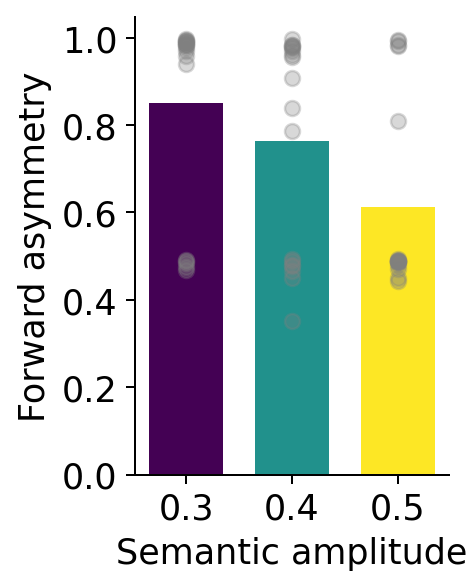

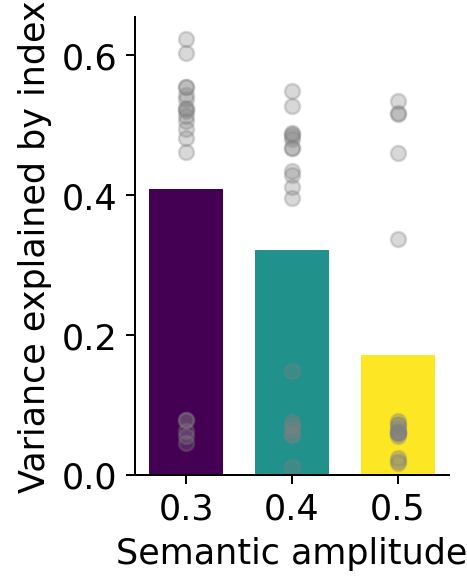

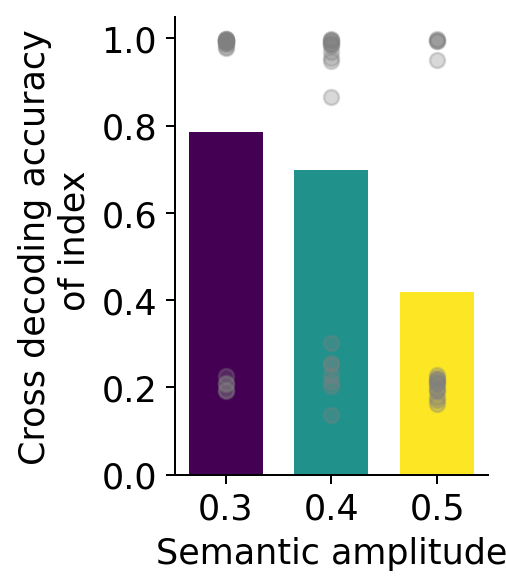

In [71]:
# bar plot of each metric for each noise std

accuracy_mean_by_noise_std = df_semantic.groupby("semantic_amp")["accuracy"].mean()
accuracy_std_by_noise_std = df_semantic.groupby("semantic_amp")["accuracy"].std()

temporal_factor_mean_by_noise_std = df_semantic.groupby("semantic_amp")["temporal_factor"].mean()
temporal_factor_std_by_noise_std = df_semantic.groupby("semantic_amp")["temporal_factor"].std()

forward_asymmetry_mean_by_noise_std = df_semantic.groupby("semantic_amp")["forward_asymmetry"].mean()
forward_asymmetry_std_by_noise_std = df_semantic.groupby("semantic_amp")["forward_asymmetry"].std()

variance_explained_index_mean_by_noise_std = df_semantic.groupby("semantic_amp")["explained_variance_index"].mean()
variance_explained_identity_mean_by_noise_std = df_semantic.groupby("semantic_amp")["explained_variance_identity"].mean()

cross_decoding_accuracy_index_mean_by_noise_std = df_semantic.groupby("semantic_amp")["cross_decoding_accuracy_index"].mean()
cross_decoding_accuracy_identity_mean_by_noise_std = df_semantic.groupby("semantic_amp")["cross_decoding_accuracy_identity"].mean()


# viridis = plt.get_cmap('viridis', lut=len(noise_stds))
# colors = [viridis(i) for i in range(len(noise_stds))]
df_semantic["mark"] = df_semantic["semantic_amp"].map(lambda x: semantic_amp.index(x)+1)

def plot_mean_scatter_bar(mean, df, df_label, noise_stds, y_label, x_ticks=None):
    plt.figure(figsize=(2.25, 3.3), dpi=180)
    plt.bar(np.arange(1, len(mean)+1), mean, width=0.7, color=colors)
    plt.scatter(df["mark"], df[df_label], color="gray", alpha=0.3)
    plt.xlabel("Semantic amplitude")
    plt.xticks(np.arange(1, len(mean)+1), semantic_amp)
    # if x_ticks is not None:
    #     plt.xticks(np.arange(0, len(mean)), x_ticks, rotation=45, fontsize=12)
    plt.ylabel(y_label)
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.show()

xticks = ["Amplitude 0.2, Discount 1", "Amplitude 0.5, Discount 1", "Amplitude 0.2, Discount 0", "Amplitude 0.5, Discount 0"]
plot_mean_scatter_bar(accuracy_mean_by_noise_std, df_semantic, "accuracy", noise_stds, "Task accuracy", xticks)
plot_mean_scatter_bar(temporal_factor_mean_by_noise_std, df_semantic, "temporal_factor", noise_stds, "Temporal organization score", xticks)
plot_mean_scatter_bar(forward_asymmetry_mean_by_noise_std, df_semantic, "forward_asymmetry", noise_stds, "Forward asymmetry", xticks)
plot_mean_scatter_bar(variance_explained_index_mean_by_noise_std, df_semantic, "explained_variance_index", noise_stds, "Variance explained by index", xticks)
plot_mean_scatter_bar(cross_decoding_accuracy_index_mean_by_noise_std, df_semantic, "cross_decoding_accuracy_index", noise_stds, "Cross decoding accuracy\n of index", xticks)


### clustering

In [38]:
""" load vary gamma """

gamma_names = ["0", "02", "04", "06", "08", "10"]
temporal_discount_factors = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
noise_levels = [0, 0.2, 0.4, 0.6, 0.8, 1]
noise_names = ["0", "02", "04", "06", "08", "1"]

data = []

data_folder = Path("./experiments/VaryAllSeq8LargeNoise/figures/ValueMemoryGRU")
training_curve_folder = Path("./experiments/VaryAllSeq8LargeNoise/saved_models/ValueMemoryGRU")
perturbation_folder = Path("./experiments/VaryAllSeq8LargeNoise/figures/perturbation/ValueMemoryGRU")
item_invariance_folder = Path("./experiments/VaryAllSeq8LargeNoise/figures/item_invariant/ValueMemoryGRU")
time_invariance_folder = Path("./experiments/VaryAllSeq8LargeNoise/figures/time_invariant/ValueMemoryGRU")
seq_len = 8

exp = "tdf"

for gamma_name, temporal_discount_factor in zip(gamma_names, temporal_discount_factors):
    for noise_name, noise_level in zip(noise_names, noise_levels):
        setup_name = "setup_gamma{}_noise{}".format(gamma_name, noise_name)

        parameters = {
            "temporal_discount_factor": temporal_discount_factor,
            "noise_level": noise_level,
            "seq_len": seq_len,
            "wm_noise": 0.1
        }
        
        training_data_length = 200
        for i in range(20):
            data_path = data_folder / setup_name / str(i)
            training_data_path = training_curve_folder / (setup_name + "-" + str(i))
            if os.path.exists(data_path/"contiguity_effect.csv") and os.path.exists(data_path/"cross_acc.npy"):
                data_single_model = load_data(data_path, training_data_path, i, exp, parameters, training_data_length)
                if data_single_model:
                    data_single_model["pretrained"] = False
                    perturbation_data = np.load(perturbation_folder / setup_name / str(i) / "perturbation_accuracies.npy")
                    data_single_model["perturbation_accuracy"] = perturbation_data
                    if os.path.exists(item_invariance_folder / setup_name / str(i) / "decoding_accuracy.npy"):
                        item_invariance_data = np.load(item_invariance_folder / setup_name / str(i) / "decoding_accuracy.npy")
                        data_single_model["item_invariance_accuracy"] = item_invariance_data
                        item_invariance_cross_phase_data = np.load(item_invariance_folder / setup_name / str(i) / "cross_phase_decoding_accuracy.npy")
                        data_single_model["item_invariance_cross_phase_accuracy"] = item_invariance_cross_phase_data
                        data_single_model["item_invariance_cross_phase_accuracy_last"] = np.min(item_invariance_cross_phase_data)
                    else:
                        data_single_model["item_invariance_accuracy"] = None
                        data_single_model["item_invariance_cross_phase_accuracy"] = None
                        data_single_model["item_invariance_cross_phase_accuracy_last"] = None
                    if os.path.exists(time_invariance_folder / setup_name / str(i) / "decoding_accuracy.npy"):
                        time_invariance_data = np.load(time_invariance_folder / setup_name / str(i) / "decoding_accuracy.npy")
                        data_single_model["time_invariance_accuracy"] = time_invariance_data
                        time_invariance_cross_phase_data = np.load(time_invariance_folder / setup_name / str(i) / "cross_phase_decoding_accuracy.npy")
                        data_single_model["time_invariance_cross_phase_accuracy"] = time_invariance_cross_phase_data
                        data_single_model["time_invariance_cross_phase_accuracy_last"] = np.min(time_invariance_cross_phase_data)
                    else:
                        data_single_model["time_invariance_accuracy"] = None
                        data_single_model["time_invariance_cross_phase_accuracy"] = None
                        data_single_model["time_invariance_cross_phase_accuracy_last"] = None
                    data.append(data_single_model)

df = pd.DataFrame(data)
print(len(df))

699


In [48]:
df_filtered = df[df["accuracy"] > 0.5]

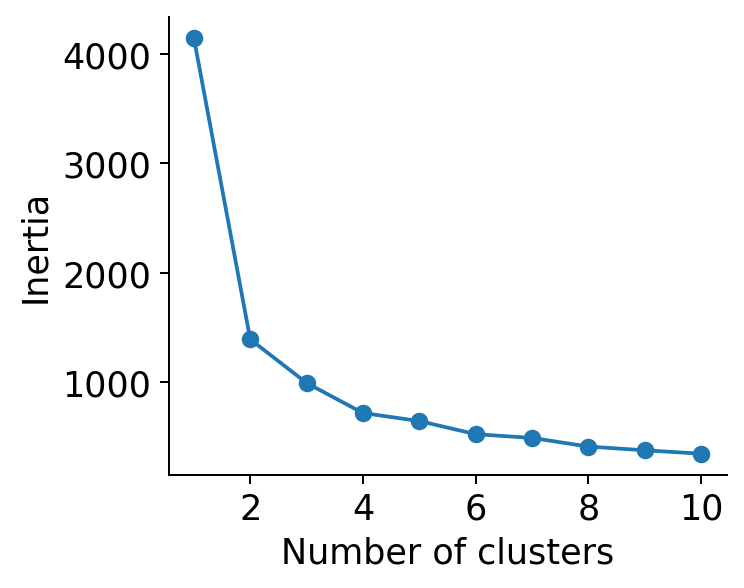

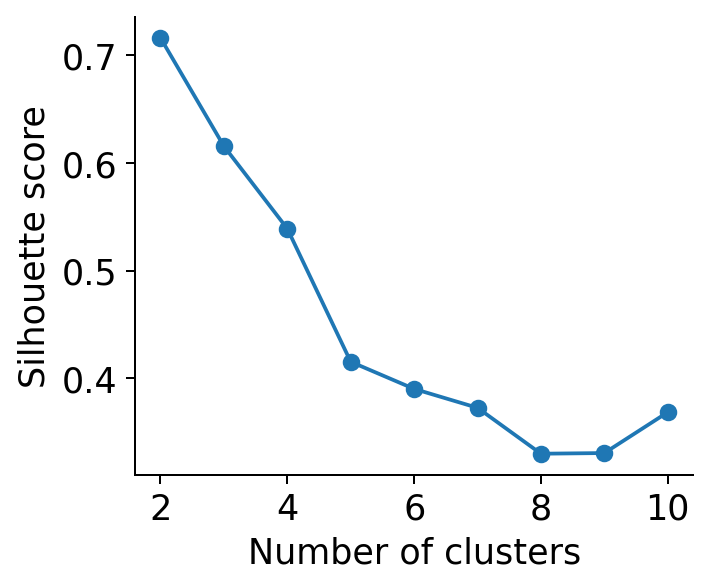

In [49]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

features = ["forward_asymmetry", "temporal_factor",
            # "index_decoding_accuracy", "item_decoding_accuracy",
            "explained_variance_index", "explained_variance_identity", 
            "cross_decoding_accuracy_index", "cross_decoding_accuracy_identity",
            # "item_invariance_cross_phase_accuracy_last", "time_invariance_cross_phase_accuracy_last"
            ]

X = df_filtered[features]

scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

# Determine the optimal number of clusters with elbow method
inertia = []
sihoutte_score = []
for n_clusters in range(1, 11):
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    kmeans.fit(X_normalized)
    labels = kmeans.labels_
    inertia.append(kmeans.inertia_)
    if n_clusters > 1:
        sihoutte_score.append(silhouette_score(X_normalized, labels))

plt.figure(figsize=(4, 3.3), dpi=180)
plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# plt.title('Inertia for Optimal Number of Clusters')
plt.show()

plt.figure(figsize=(4, 3.3), dpi=180)
plt.plot(range(2, 11), sihoutte_score, marker='o')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')
ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()

In [50]:
# make the optimal number of clusters\

# Fit the KMeans model with the optimal number of clusters
optimal_clusters = 3
kmeans = KMeans(n_clusters=optimal_clusters, random_state=42)
cluster_labels = kmeans.fit_predict(X_normalized)
df_filtered.loc[:, 'cluster'] = cluster_labels

# Add silhouette score to evaluate clustering quality
silhouette_avg = silhouette_score(X_normalized, cluster_labels)
print(f'Silhouette Score for {optimal_clusters} clusters: {silhouette_avg}')



# print number of items for each cluster
for i in range(optimal_clusters):
    print(f'Cluster {i+1}: {len(df_filtered[df_filtered["cluster"] == i])} items')
# print 5 info for each cluster
for i in range(optimal_clusters):
    print(f'Cluster {i+1}:')
    print(df_filtered[df_filtered['cluster'] == i][["temporal_discount_factor", "noise_level", "model_num"]].tail())

Silhouette Score for 3 clusters: 0.6155310858003222
Cluster 1: 534 items
Cluster 2: 98 items
Cluster 3: 59 items
Cluster 1:
     temporal_discount_factor  noise_level  model_num
651                       1.0          0.6         12
655                       1.0          0.6         16
658                       1.0          0.6         19
660                       1.0          0.8          1
665                       1.0          0.8          6
Cluster 2:
     temporal_discount_factor  noise_level  model_num
694                       1.0          1.0         15
695                       1.0          1.0         16
696                       1.0          1.0         17
697                       1.0          1.0         18
698                       1.0          1.0         19
Cluster 3:
     temporal_discount_factor  noise_level  model_num
669                       1.0          0.8         10
671                       1.0          0.8         12
672                       1.0          0.8  

/state/partition1/job-3255965/ipykernel_3110434/2065337568.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered.loc[:, 'cluster'] = cluster_labels


In [51]:
df_filtered = df_filtered[(df_filtered["temporal_discount_factor"] == 1.0) | (df_filtered["noise_level"] == 1.0)]
print(len(df_filtered))

# print number of items for each cluster
for i in range(optimal_clusters):
    print(f'Cluster {i+1}: {len(df_filtered[df_filtered["cluster"] == i])} items')
# print 5 info for each cluster
for i in range(optimal_clusters):
    print(f'Cluster {i+1}:')
    print(df_filtered[df_filtered['cluster'] == i][["temporal_discount_factor", "noise_level", "model_num"]].tail())

209
Cluster 1: 54 items
Cluster 2: 98 items
Cluster 3: 57 items
Cluster 1:
     temporal_discount_factor  noise_level  model_num
651                       1.0          0.6         12
655                       1.0          0.6         16
658                       1.0          0.6         19
660                       1.0          0.8          1
665                       1.0          0.8          6
Cluster 2:
     temporal_discount_factor  noise_level  model_num
694                       1.0          1.0         15
695                       1.0          1.0         16
696                       1.0          1.0         17
697                       1.0          1.0         18
698                       1.0          1.0         19
Cluster 3:
     temporal_discount_factor  noise_level  model_num
669                       1.0          0.8         10
671                       1.0          0.8         12
672                       1.0          0.8         13
675                       1.0          

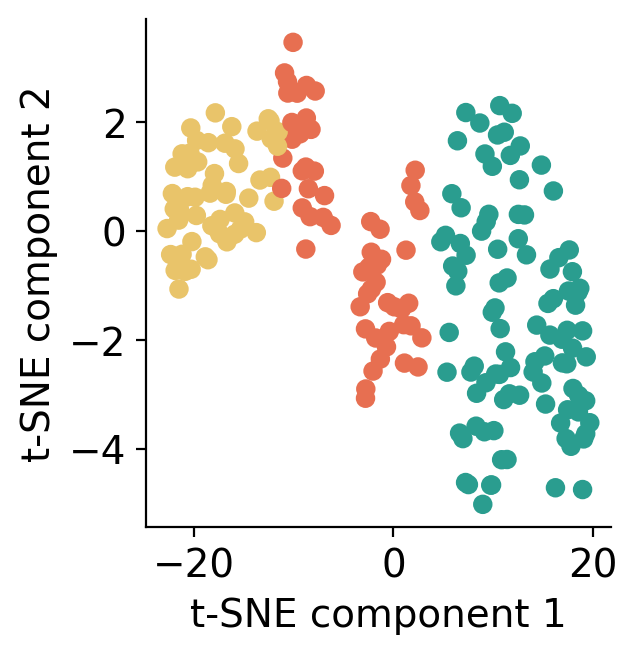

In [58]:
from sklearn.manifold import TSNE

colormap = np.array(["#E9C46A", "#2A9D8F", "#E76F51", "#F4A261", "#264653"]) 

# patches = [mpatches.Patch(color="#2A9D8F", label="Strategy 1: Memory palace"),
#            mpatches.Patch(color="#E76F51", label="Strategy 2: TCM-like forward"),
#            mpatches.Patch(color="#E9C46A", label="Strategy 3: Backward recall"),
#            mpatches.Patch(color="#264653", label="Reservoir RNN")]


features = ["forward_asymmetry", "temporal_factor",
            # "index_decoding_accuracy", "item_decoding_accuracy", 
            "explained_variance_index", "explained_variance_identity", 
            # "item_invariance_cross_phase_accuracy_last", "time_invariance_cross_phase_accuracy_last",
            "cross_decoding_accuracy_index", "cross_decoding_accuracy_identity"
            ]

X_tsne = df_filtered[features]

scaler = StandardScaler()
X_tsne_normalized = scaler.fit_transform(X_tsne)
cluster_labels = df_filtered["cluster"]

# Perform t-SNE on the normalized data
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_tsne_normalized)

# Plot the t-SNE results with cluster labels
plt.figure(figsize=(3, 3.3), dpi=200)
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=colormap[cluster_labels])
# plt.title('t-SNE visualization of clusters')
plt.xlabel('t-SNE component 1')
plt.ylabel('t-SNE component 2')

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.show()


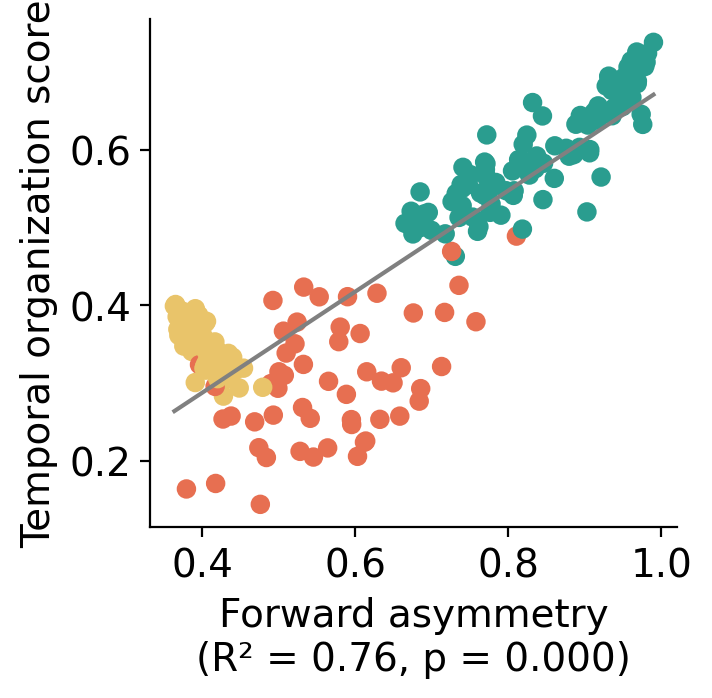

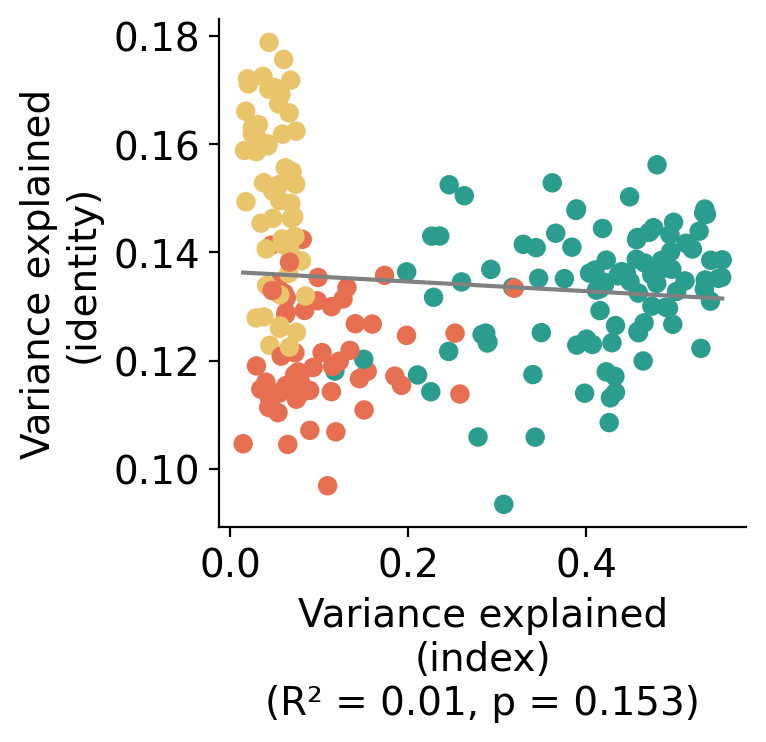

In [59]:
# plot scatter with cluster labels

def plot_scatter_cluster(df, x, y, c, x_label, y_label, fit=True, plot_reservoir=True):
    plt.figure(figsize=(3.4, 3.3), dpi=200)

    plt.scatter(df[x], df[y], c=colormap[df[c].iloc[:]])

    if fit:
        if plot_reservoir:
            # plot for reservoir and tcm
            plt.scatter(df_reservoir[x], df_reservoir[y], c=colormap[-1])
            # plt.scatter(df_tcm[x], df_tcm[y], c=colormap[-1])
    
        # Reshape x and y for sklearn
        x_reshaped = np.array(df[x]).reshape(-1, 1)
        y_reshaped = np.array(df[y]).reshape(-1, 1)

        # Fit linear regression model
        model = LinearRegression()
        model.fit(x_reshaped, y_reshaped)

        # Predict y values
        sorted_x_idx = np.argsort(x_reshaped.reshape(-1))
        x1, x2 = x_reshaped[sorted_x_idx[0]], x_reshaped[sorted_x_idx[-1]]
        y_pred = model.predict(x_reshaped)
        y1, y2 = y_pred[sorted_x_idx[0]], y_pred[sorted_x_idx[-1]]

        # Calculate R-squared
        r2 = r2_score(y_reshaped, y_pred)
        # Calculate the p-value for the regression
        _, p_value = stats.pearsonr(x_reshaped.flatten(), y_reshaped.flatten())
        
        # Plot the regression line
        plt.plot([x1, x2], [y1, y2], color="grey")

        x_label = x_label+"\n(R² = {:.2f}, p = {:.3f})".format(r2, p_value)

    plt.xlabel(x_label)
    plt.ylabel(y_label)

    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    # plt.tight_layout()
    plt.show()

plot_scatter_cluster(df_filtered, 'forward_asymmetry', 'temporal_factor', 'cluster', 'Forward asymmetry', 'Temporal organization score', plot_reservoir=False)
plot_scatter_cluster(df_filtered, 'explained_variance_index', 'explained_variance_identity', 'cluster', 'Variance explained\n(index)', 'Variance explained\n(identity)', plot_reservoir=False)

In [100]:
features = ["forward_asymmetry", "temporal_factor",
            # "index_decoding_accuracy", "item_decoding_accuracy",
            "explained_variance_index", "explained_variance_identity", 
            "cross_decoding_accuracy_index", "cross_decoding_accuracy_identity",
            # "item_invariance_cross_phase_accuracy_last", "time_invariance_cross_phase_accuracy_last"
            ]



X = df_ctx[features]
X_normalized = scaler.transform(X)

cluster_labels_ctx = kmeans.predict(X_normalized)
df_ctx.loc[:, "cluster"] = cluster_labels_ctx

print(cluster_labels_ctx)

# Swap cluster labels 0 and 1 in df_ctx['cluster']
df_ctx['cluster'] = df_ctx['cluster'].map({0: 1, 1: 0}).fillna(df_ctx['cluster']).astype(int)




[0 0 2 0 2 0 0 0 0 0 0 0 0 1 0 0 0 0 0 2 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 2 0 0 0 0 0 0 0 2 0 2 2 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 2 2 1 1 1 1 1 2 1 1 2 2 1 2 2 2 1 2 1 2]


In [101]:
# distribution of strategies in each factor

def plot_bar_by_strategy(df, x, x_label):
    plt.figure(figsize=(2.2, 3.3), dpi=180)
    
    cluster_distribution = df.groupby(["cluster", x]).size().unstack(fill_value=0)
    sum_distribution = cluster_distribution.sum(axis=0)
    cluster_distribution = cluster_distribution.div(sum_distribution, axis=1)
    cumsum_distribution = cluster_distribution.cumsum(axis=0)

    for i, row in cumsum_distribution.iterrows():
        plt.bar(np.arange(0, len(row.index)), row.values, color=colormap[i], label=f"Cluster {i}", width=0.7, zorder=-i)
    plt.xlabel(x_label)
    plt.ylabel("Distribution of strategies")

    unique_x = df[x].unique()
    plt.xticks(np.arange(0, len(unique_x)), list(unique_x))
    
    ax = plt.gca()
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.show()


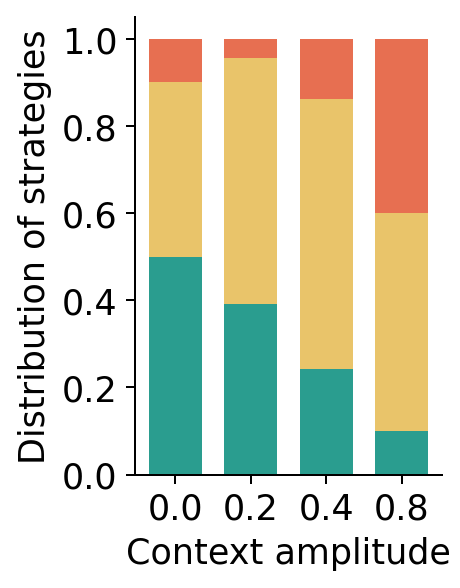

In [102]:

colormap = np.array(["#2A9D8F", "#E9C46A", "#E76F51", "#F4A261", "#264653"]) 

# patches = [mpatches.Patch(color="#2A9D8F", label="Strategy 1: Memory palace"),
#            mpatches.Patch(color="#E76F51", label="Strategy 2: TCM-like forward"),
#            mpatches.Patch(color="#E9C46A", label="Strategy 3: Backward recall"),
#            mpatches.Patch(color="#264653", label="Reservoir RNN")]

plot_bar_by_strategy(df_ctx, "noise_std", "Context amplitude")

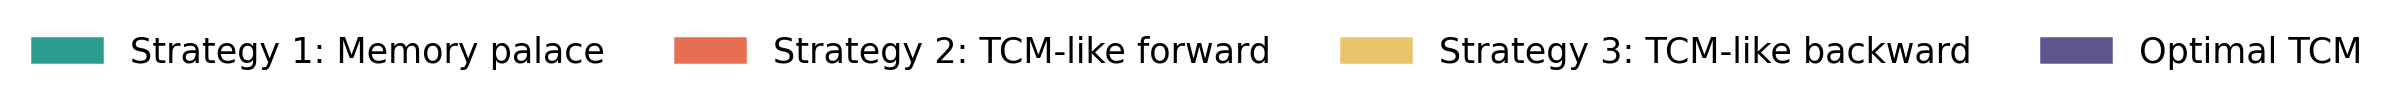

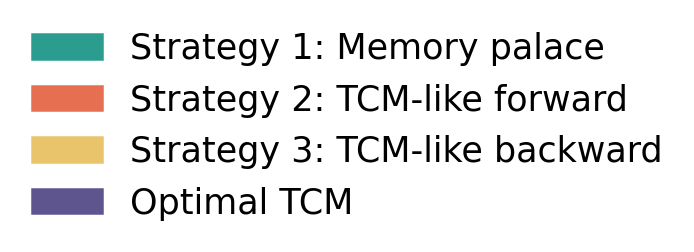

In [88]:
# Create a legend for the colormap
import matplotlib.patches as mpatches

# Define labels for the legend
legend_labels = ['Cluster 1', 'Cluster 2', 'Cluster 3', 'Cluster 4', 'Cluster 5']

# Create a list of patches for the legend
patches = [mpatches.Patch(color="#2A9D8F", label="Strategy 1: Memory palace"),
           mpatches.Patch(color="#E76F51", label="Strategy 2: TCM-like forward"),
           mpatches.Patch(color="#E9C46A", label="Strategy 3: TCM-like backward"),
           mpatches.Patch(color="#5E548E", label="Optimal TCM")]
        #    mpatches.Patch(color="#264653", label="TCM")]
# [mpatches.Patch(color=colormap[i], label=legend_labels[i]) for i in range(optimal_clusters)]

# Plot the legend
plt.figure(figsize=(8, 0.5), dpi=180)
plt.legend(handles=patches, loc='center', ncol=optimal_clusters+1, frameon=False)
plt.axis('off')
plt.show()

plt.figure(figsize=(2, 0.5), dpi=180)
plt.legend(handles=patches, loc='center', frameon=False)
plt.axis('off')
plt.show()